In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

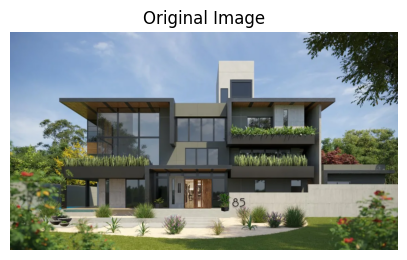

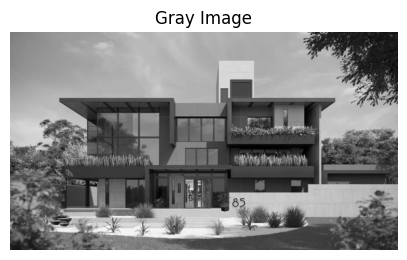

In [6]:
img = cv2.imread('image5.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show("Original Image", cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
show("Gray Image", gray)

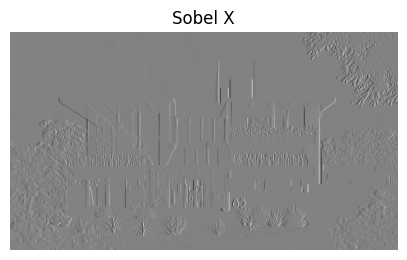

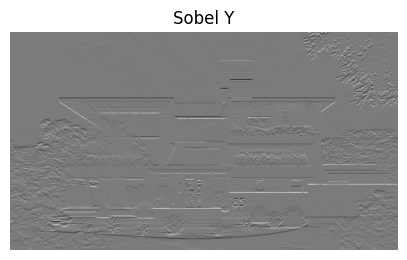

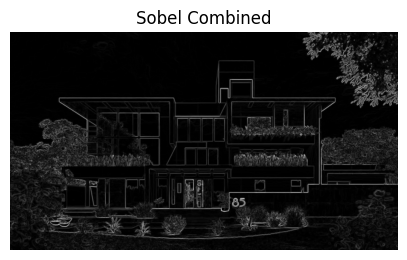

In [7]:
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

sobel = cv2.magnitude(sobel_x, sobel_y)

show("Sobel X", sobel_x)
show("Sobel Y", sobel_y)
show("Sobel Combined", sobel)

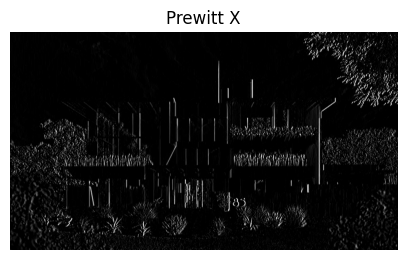

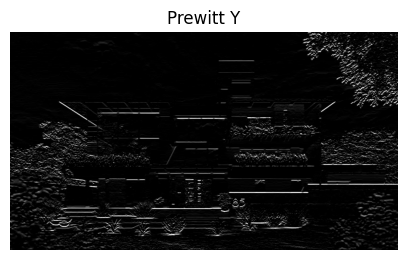

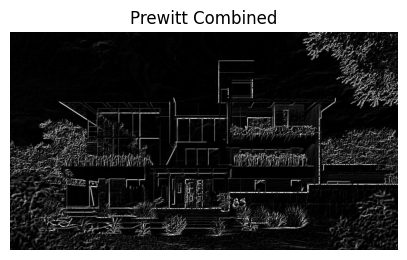

In [8]:
kernel_x = np.array([[-1,0,1],
                     [-1,0,1],
                     [-1,0,1]])

kernel_y = np.array([[-1,-1,-1],
                     [ 0, 0, 0],
                     [ 1, 1, 1]])

prewitt_x = cv2.filter2D(gray, -1, kernel_x)
prewitt_y = cv2.filter2D(gray, -1, kernel_y)

prewitt = prewitt_x + prewitt_y

show("Prewitt X", prewitt_x)
show("Prewitt Y", prewitt_y)
show("Prewitt Combined", prewitt)

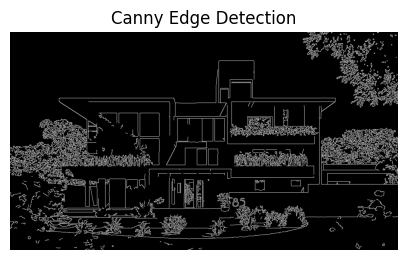

In [9]:
canny = cv2.Canny(gray, 100, 200)
show("Canny Edge Detection", canny)

(np.float64(-0.5), np.float64(1141.5), np.float64(641.5), np.float64(-0.5))

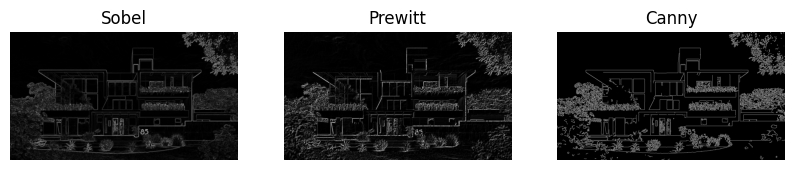

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(sobel, cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(prewitt, cmap='gray')
plt.title("Prewitt")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(canny, cmap='gray')
plt.title("Canny")
plt.axis('off')

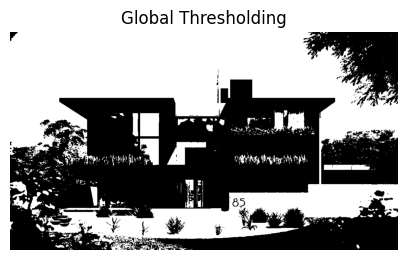

In [11]:
_, thresh_global = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
show("Global Thresholding", thresh_global)

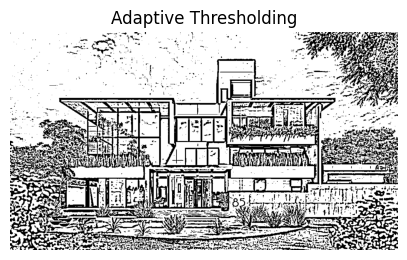

In [12]:
thresh_adaptive = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

show("Adaptive Thresholding", thresh_adaptive)

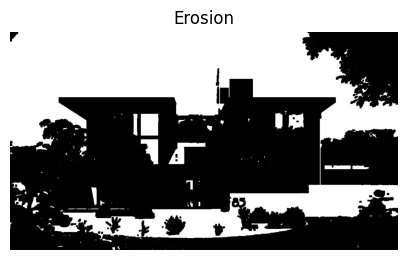

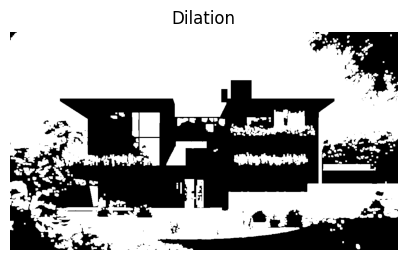

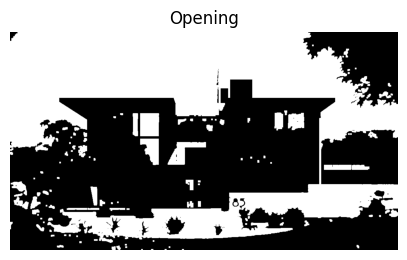

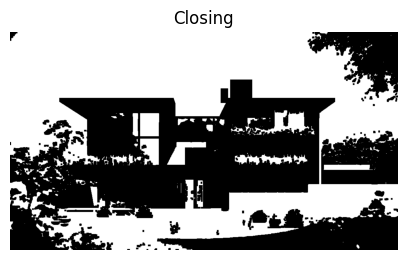

In [13]:
kernel = np.ones((5,5), np.uint8)

erosion = cv2.erode(thresh_global, kernel, iterations=1)
dilation = cv2.dilate(thresh_global, kernel, iterations=1)
opening = cv2.morphologyEx(thresh_global, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh_global, cv2.MORPH_CLOSE, kernel)

show("Erosion", erosion)
show("Dilation", dilation)
show("Opening", opening)
show("Closing", closing)

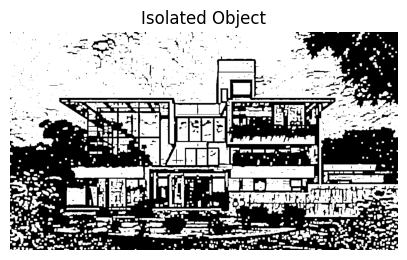

In [14]:
clean_object = cv2.morphologyEx(thresh_adaptive, cv2.MORPH_OPEN, kernel)
show("Isolated Object", clean_object)